In [178]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 
from mpl_toolkits.mplot3d import axes3d
import matplotlib.cm as cm

1D Heat Equation
$$u_t = \alpha^2 u_{xx}$$

In [179]:
# Define spatial domain, number of spatial discretization points, 
# and thermal diffusivity constant, alpha. 
L = 100
N = 100
dx = L/N
a = 1
x = np.linspace((-L/2), (L/2), num=N)


In [180]:
# Define temporal domain and temporal discretization size. 
t_0 = 0
t_f = 10
dt = 0.001
M = (t_f - t_0)/dt
t = np.linspace(t_0, t_f+dt, int(M))

In [181]:
# Define temperature array shaped like spatial domain
u = np.zeros((len(x), len(t))) 

# Define initial condition at -10 < x < 10 to be equal to 10 and zero everywhere else
u[np.where((x>-10) & (x<10)), 0] = 100


In [182]:
# Ensure we have a valid courant number. Co must be less than one. 
Co = u.max() * dt / dx

if Co < 1:
    print('CFL condition satisfied.')
else:
    print('Decrease time step size.')

CFL condition satisfied.


In [183]:
# Solve heat equation using Finite Difference Method
for i in range(0, len(t)-1):  # time step loop
    for j in range(1, len(x)-1):  # spatial loop
        u[j, i+1] = (a**2 * dt / dx**2) * ((u[j+1, i] - 2*u[j, i] + u[j-1, i])) + u[j, i]


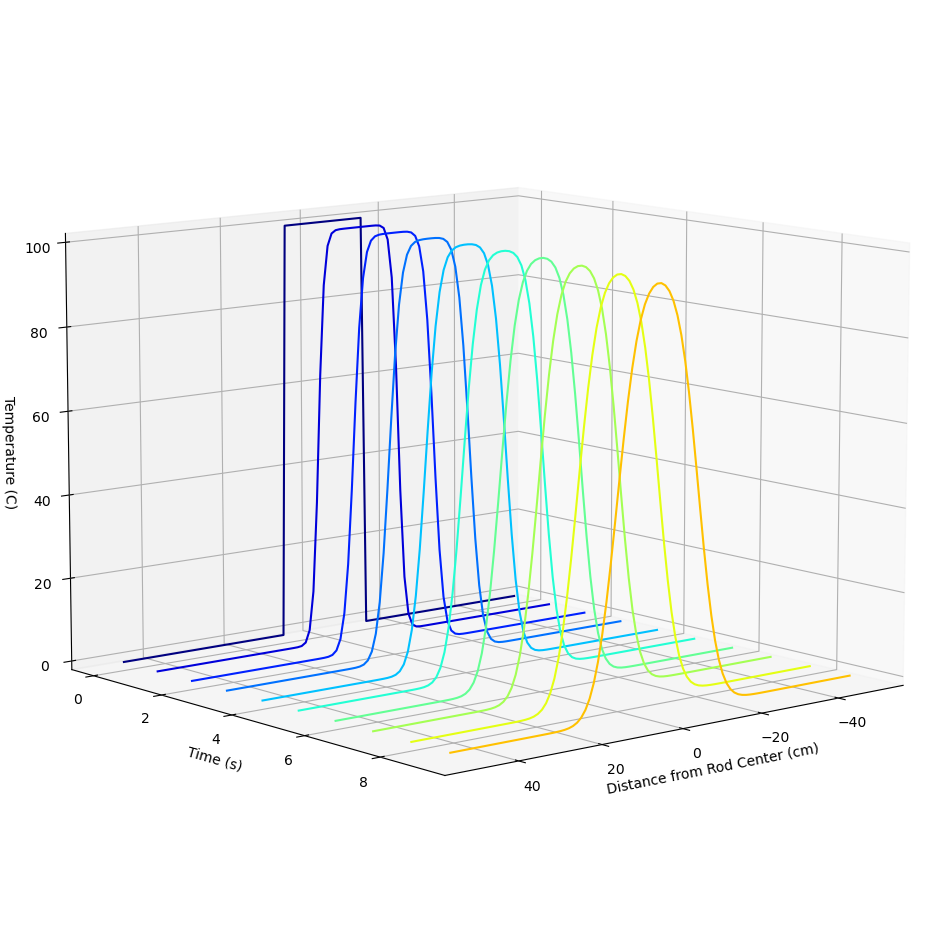

In [184]:
# Visualize the solution and behavior of the system. 
%matplotlib inline

fig = plt.figure(0, figsize=(12, 12), constrained_layout=False)
ax = fig.add_subplot(111, projection='3d')
plt.set_cmap('jet_r')
u_plot = u[:, 0:-1:1000]
for k in range(u_plot.shape[1]):
    ys = k*np.ones(u_plot.shape[0])
    ax.plot(x, ys, u_plot[:, k], color=cm.jet(k*20))

ax.set_xlabel('Distance from Rod Center (cm)')
ax.set_ylabel('Time (s)')
ax.set_zlabel('Temperature (C)')
ax.view_init(10, 50)
plt.show()

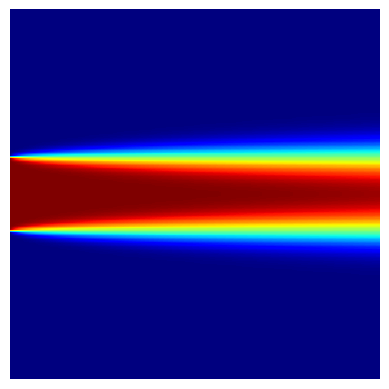

In [185]:
# Second visualization technique in a 2D plane. 
# X axis is time and y axis is spatial location. 
# Each pixel is colored by the u(x, t) value at that point. 

plt.figure()
plt.imshow(u, aspect=100)
plt.axis('off')
plt.set_cmap('jet')
plt.show()

In [186]:
# Perform SVD/POD decomposition on our snapshot matrix from our FDM solution. 
X = np.array(u, copy=True)
Uhat, Sighat, VThat = np.linalg.svd(X)

In [187]:
# Note that the length of dimensionality of our U columns is equal to that of 
# our spatial discretization. 
print(len(Sighat))

100


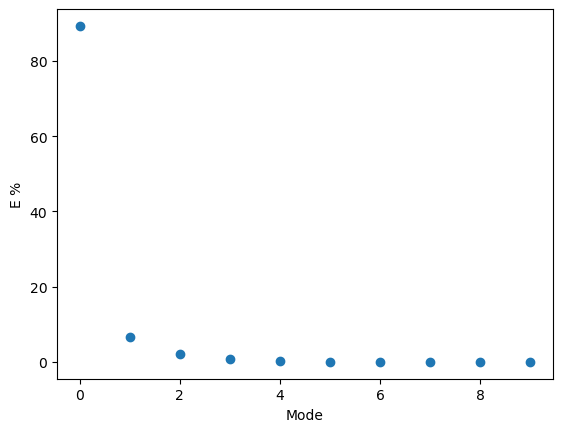

In [188]:
# Although we did this in our last article, we can visualize the most energetic
# modes in of our POD decomposition. 

E = Sighat/np.sum(Sighat) * 99
E.shape

plt.figure()
plt.scatter(range(len(E[0:10])), E[0:10])
plt.ylabel('E %')
plt.xlabel('Mode')
plt.show()

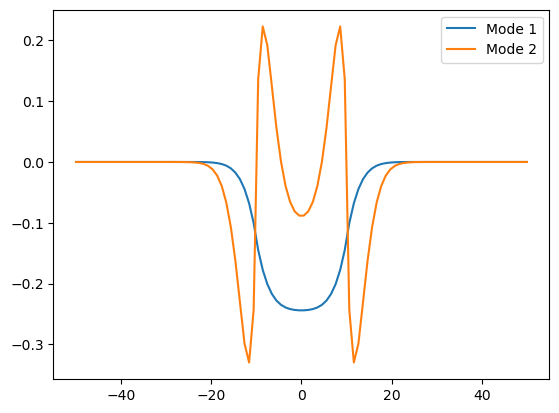

In [189]:
# If so inclined, visualize our top two most energetic modes. 

plt.figure()
plt.plot(x, Uhat[:, 0], label='Mode 1')
plt.plot(x, Uhat[:, 1], label='Mode 2')
plt.legend()
plt.show()

### Performing Galerking Projection of our PDE onto our POD Modes
It's at this point that we diverge from our last worked example. From here on, 
we will be programming the Galerkin projection laid out in Part 3 of our series.

1. We first need to calculate the first and second spatial derivatives of our 
two basis modes. 
2. From there, we will convert our initial conditions into conditions for 
a_0(0) and a_1(0).
3. We'll setup our problem in matrix form and apply solve_ivp to solve our 
set of ODEs
4. Lastly, we'll visualize the result and see how our reduced order (2 dimensional),
system compares to our full fidelity (100 dimensional) FDM system.

In [190]:
# Compute derivatives of first eigenvector
sci1_x = np.gradient(Uhat[:, 0], x)
sci1_xx = np.gradient(sci1_x, x)

# Compute the derivatives of the second eigenvector
sci2_x = np.gradient(Uhat[:, 1], x)
sci2_xx = np.gradient(sci2_x, x)

In [191]:
# Define initial condtion for a_0 and a_1  
a_0 = np.inner(u[:, 0], Uhat[:, 0])
a_1 = np.inner(u[:, 0], Uhat[:, 1])

'''

We setup our system of ODEs in matrix form:

a_0 = i*a_0 + j*a_1
a_1 = k*a_0 + l*a_1

A = [a_0, a_1]
coeffs = [[i, j], [k, l]]
A = coeffs*A

'''

# ODEs
i = np.inner(sci1_xx, Uhat[:, 0])
j = np.inner(sci2_xx, Uhat[:, 0])
k = np.inner(sci1_xx, Uhat[:, 1])
l = np.inner(sci2_xx, Uhat[:, 1])

# Coefficient array
coeffs = np.array([[i, j], [k, l]])

# Define IC array
IC_arr = [a_0, a_1]

G = lambda t, A, coeffs, a: (a**2) * (coeffs @ A)

# Use ODE solver
galerkin = scipy.integrate.solve_ivp(G, [t_0, t_f+dt], IC_arr, t_eval=t, vectorized=True, args=[coeffs, a])

In [192]:
print(galerkin.y)

[[-434.50920378 -434.50167639 -434.49415009 ... -385.83408828
  -385.83041614 -385.82674409]
 [  91.7108058    91.67392593   91.6370564  ...  -30.56248652
   -30.56446664  -30.56644612]]


In [193]:
u_pod2 = galerkin.y[0, -1] * Uhat[:, 0] + galerkin.y[1:, -1] * Uhat[:, 1]
u_gp = Uhat[:, 0].reshape(100, 1) @ galerkin.y[0, :].reshape(1, 10000) + Uhat[:, 1].reshape(100, 1) @ galerkin.y[1, :].reshape(1, 10000)

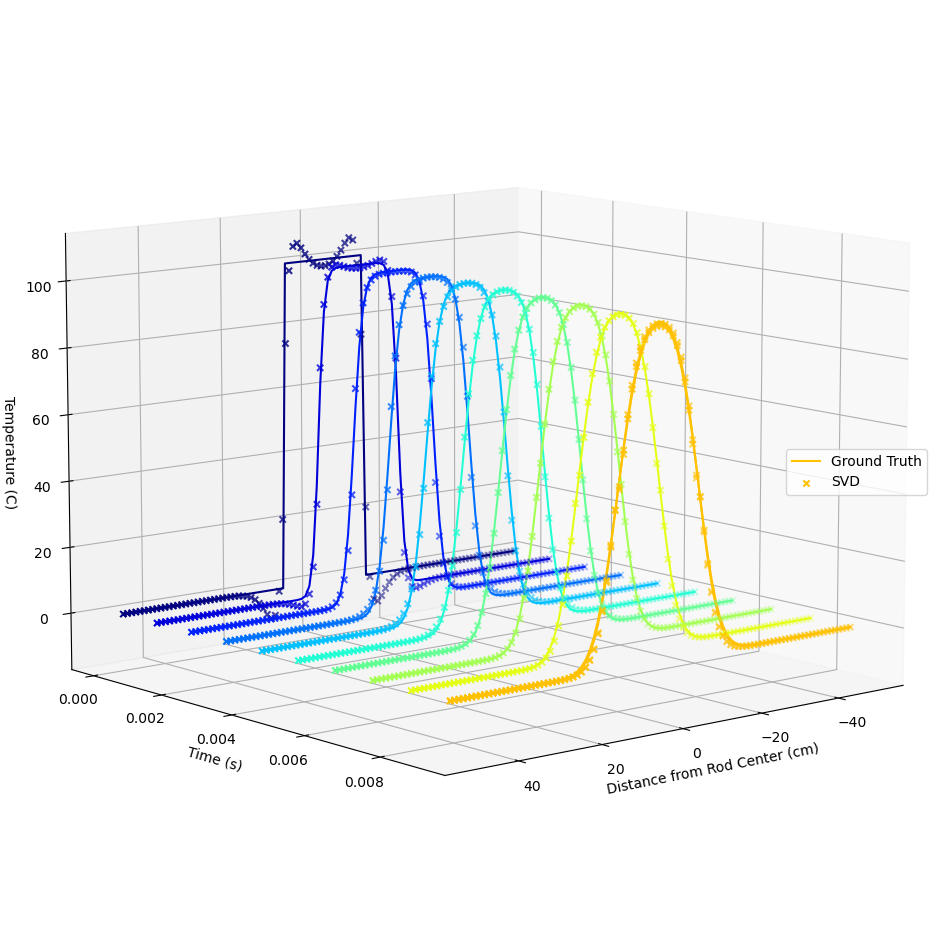

In [194]:
import matplotlib.patches as patches

fig = plt.figure(0, figsize=(12, 12), constrained_layout=False)
ax = fig.add_subplot(111, projection='3d')
plt.set_cmap('jet_r')
for k in range(u[:, ::1000].shape[1]):
    ys = k*np.ones(u[:, ::1000].shape[0])/1000
    ax.plot(x, ys, u[:, k*1000], color=cm.jet(k*20))
    ax.scatter(x, ys, u_gp[:, k*1000], color=cm.jet(k*20), marker='x')
    if k == 9:
        ax.plot(x, ys, u[:, -1], color=cm.jet(k*20), label='Ground Truth')
        ax.scatter(x, ys, u_gp[:, -1], color=cm.jet(k*20), marker='x', label='Galerkin-ROM')



ax.set_xlabel('Distance from Rod Center (cm)')
ax.set_ylabel('Time (s)')
ax.set_zlabel('Temperature (C)')
ax.view_init(10, 50)
plt.legend(loc='center right')
plt.show()

### Testing with Unseen Initial Conditions

In [195]:
# Initialization
# Define temperature array shaped like spatial domain
u = np.zeros((len(x), len(t))) 

# Define initial condition at -10 < x < 10 to be equal to 72 and zero everywhere else
u[np.where((x>-10) & (x<10)), 0] = 72

In [196]:
# Finite Difference Method for comparison
for i in range(0, len(t)-1):  # time step loop
    for j in range(1, len(x)-1):  # spatial loop
        u[j, i+1] = (a**2 * dt / dx**2) * ((u[j+1, i] - 2*u[j, i] + u[j-1, i])) + u[j, i]


In [197]:
# Define initial conditions
a_0 = np.inner(u[:, 0], Uhat[:, 0])
a_1 = np.inner(u[:, 0], Uhat[:, 1])


i = np.inner(sci1_xx, Uhat[:, 0])
j = np.inner(sci2_xx, Uhat[:, 0])
k = np.inner(sci1_xx, Uhat[:, 1])
l = np.inner(sci2_xx, Uhat[:, 1])

# Coefficient array
coeffs = np.array([[i, j], [k, l]])

# Define IC array
IC_arr = [a_0, a_1]

G = lambda t, A, coeffs, a: (a**2) * (coeffs @ A)

# Use ODE solver
galerkin = scipy.integrate.solve_ivp(G, [t_0, t_f+dt], IC_arr, t_eval=t, vectorized=True, args=[coeffs, a])

In [198]:
u_gp = Uhat[:, 0].reshape(100, 1) @ galerkin.y[0, :].reshape(1, 10000) + Uhat[:, 1].reshape(100, 1) @ galerkin.y[1, :].reshape(1, 10000)
u_svd = Uhat[:, 0:2]*Sighat[0:2] @ VThat[0:2, :]

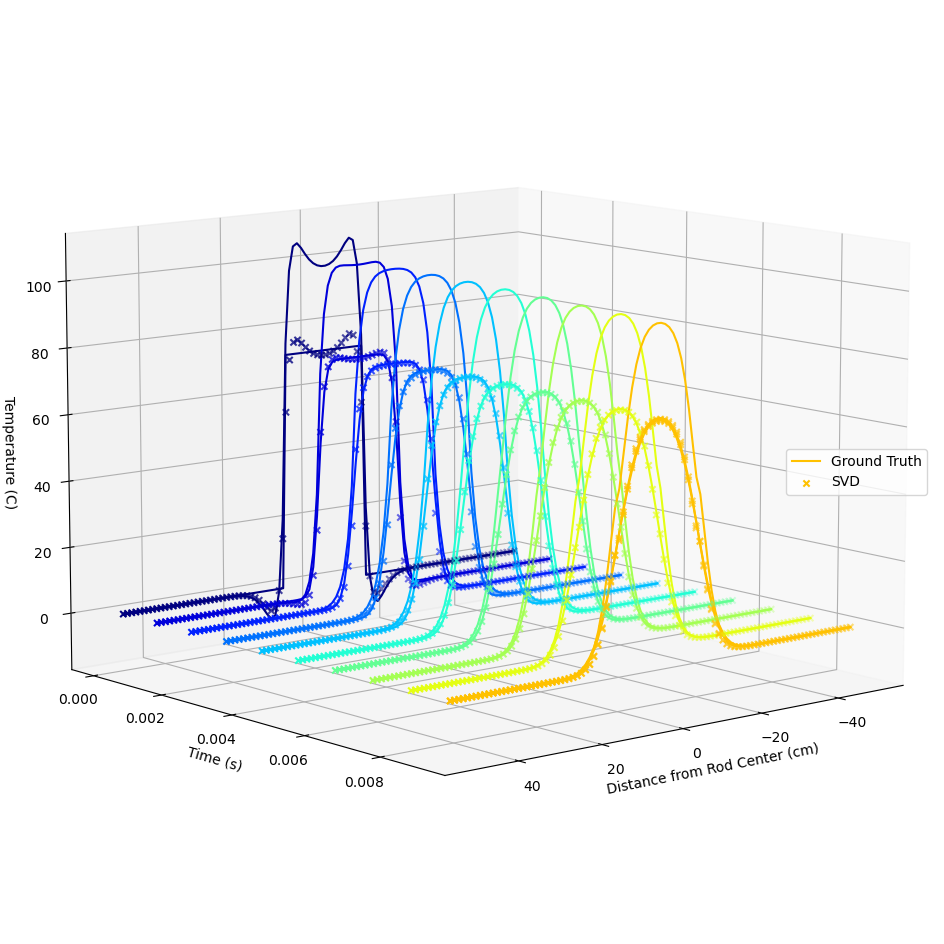

In [199]:
import matplotlib.patches as patches

fig = plt.figure(0, figsize=(12, 12), constrained_layout=False)
ax = fig.add_subplot(111, projection='3d')
plt.set_cmap('jet_r')
for k in range(u[:, ::1000].shape[1]):
    ys = k*np.ones(u[:, ::1000].shape[0])/1000
    ax.plot(x, ys, u[:, k*1000], color=cm.jet(k*20))
    ax.plot(x, ys, u_svd[:, k*1000], color=cm.jet(k*20))
    ax.scatter(x, ys, u_gp[:, k*1000], color=cm.jet(k*20), marker='x')
    if k == 9:
        ax.plot(x, ys, u[:, -1], color=cm.jet(k*20), label='Ground Truth')
        ax.scatter(x, ys, u_gp[:, -1], color=cm.jet(k*20), marker='x', label='Galerkin-ROM')



ax.set_xlabel('Distance from Rod Center (cm)')
ax.set_ylabel('Time (s)')
ax.set_zlabel('Temperature (C)')
ax.view_init(10, 50)
plt.legend(loc='center right')
plt.show()